# 03 - Customer Segmentation (RFM)

**Input**: `clean_transactions.parquet` (notebook 01)

**Output**: `customer_segments.parquet`

---

## Business Context & Objectives

This notebook builds an RFM segmentation on the customer base prepared in notebook 01, using Recency, Frequency and Monetary value. Two methods are applied in parallel: quantile-based scoring, which is the operational standard in retail, and k-means clustering, which is statistically grounded but less directly actionable.

Running both is deliberate. If two unrelated methods converge on the same customers, the structure is in the data rather than in the method.

### Research questions

1. How do customers distribute across Recency, Frequency and Monetary value?
2. Do quantile scoring and k-means produce the same segments, and where do they disagree?
3. Are the segments stable if the reference date or the cancellation-netting rule changes?

### Plan

0. Setup and loading
1. Cancellation netting decision
2. Building the RFM table
3. RFM distributions
4. Quantile-based segmentation
5. K-means clustering
6. Comparing the two approaches
7. Stability testing
8. Segment profiles and revenue share
9. Export

# 0. Setup & Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from pathlib import Path
from IPython.display import display, Markdown

PROC = Path("../data/processed")
clean = pd.read_parquet(PROC / "clean_transactions.parquet")

display(Markdown(f"""
### Input
* **Rows:** `{len(clean):,}`
* **Unique customers:** `{clean['Customer ID'].nunique():,}`
* **Date range:** `{clean['InvoiceDate'].min()}` to `{clean['InvoiceDate'].max()}`
"""))



### Input
* **Rows:** `820,947`
* **Unique customers:** `5,880`
* **Date range:** `2009-12-01 07:45:00` to `2011-12-09 12:50:00`


**Results.** 820,947 rows covering 5,880 customers, spanning 1 December 2009 to 9 December 2011. These figures match the export from notebook 01.

# 1. Cancellation Netting Decision

Notebook 01 flagged cancellations through `IsCancellation` but deliberately did not net them out of the shared base, since the right treatment depends on the analysis.

For customer monetary value, the decision here is to **net cancellations into `Monetary`**. A customer's value should reflect what they actually kept, not their gross ordering activity, and a cancelled order is not revenue.

A separate signal is preserved alongside it: CancellationRate, the share of a customer's invoices that were cancelled. Netting collapses purchases and cancellations into a single figure, so a customer who orders twice and cancels once becomes indistinguishable from one who orders once and never cancels. Keeping the rate as its own column preserves that distinction for reporting and targeting.

# 2. Building the RFM Table

In [2]:
REFERENCE_DATE = clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = clean.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (REFERENCE_DATE - x.max()).days),
    Frequency=("Invoice", lambda x: x[~clean.loc[x.index, "IsCancellation"]].nunique()),
    Monetary=("LineRevenue", "sum"),
    TotalInvoices=("Invoice", "nunique"),
    CancelledInvoices=("Invoice", lambda x: x[clean.loc[x.index, "IsCancellation"]].nunique()),
).reset_index()

rfm["CancellationRate"] = (rfm["CancelledInvoices"] / rfm["TotalInvoices"]).fillna(0)

display(Markdown(f"**Reference date:** `{REFERENCE_DATE}`"))
display(Markdown(f"**Customers in RFM table:** `{len(rfm):,}`"))
display(rfm.describe().round(2))


C:\Users\jboul\AppData\Local\Temp\ipykernel_18660\2779221728.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  REFERENCE_DATE = clean["InvoiceDate"].max() + pd.Timedelta(days=1)


**Reference date:** `2011-12-10 12:50:00`

**Customers in RFM table:** `5,880`

,Recency,Frequency,Monetary,TotalInvoices,CancelledInvoices,CancellationRate
count,5880.00,5880.00,5880.00,5880.00,5880.00,5880.00
mean,199.59,6.23,2844.96,7.47,1.24,0.12
std,209.45,12.76,14122.74,15.40,3.32,0.17
min,1.00,0.00,-1343.24,1.00,0.00,0.00
25%,24.75,1.00,331.64,2.00,0.00,0.00
50%,94.00,3.00,854.14,4.00,0.00,0.00
75%,379.00,7.00,2214.72,8.00,1.00,0.20
max,739.00,376.00,606243.25,469.00,93.00,1.00


**Results.** 5,880 customers, with a reference date of 10 December 2011, one day after the last transaction.

The distributions are heavily right-skewed on all three dimensions. `Monetary` has a median of £854 against a mean of £2,845 and a maximum of £606,243. `Frequency` has a median of 3 orders against a maximum of 376. `Recency` spans 1 to 739 days with a median of 94.

`Monetary` reaches a minimum of -£1,343, which is a direct consequence of the netting decision: these are customers whose cancellations exceed their kept purchases. Mean cancellation rate is 12%.

The skew is expected for a wholesale-oriented business and rules out any method that assumes symmetry without transformation, which section 5 addresses.

# 3. RFM Distributions

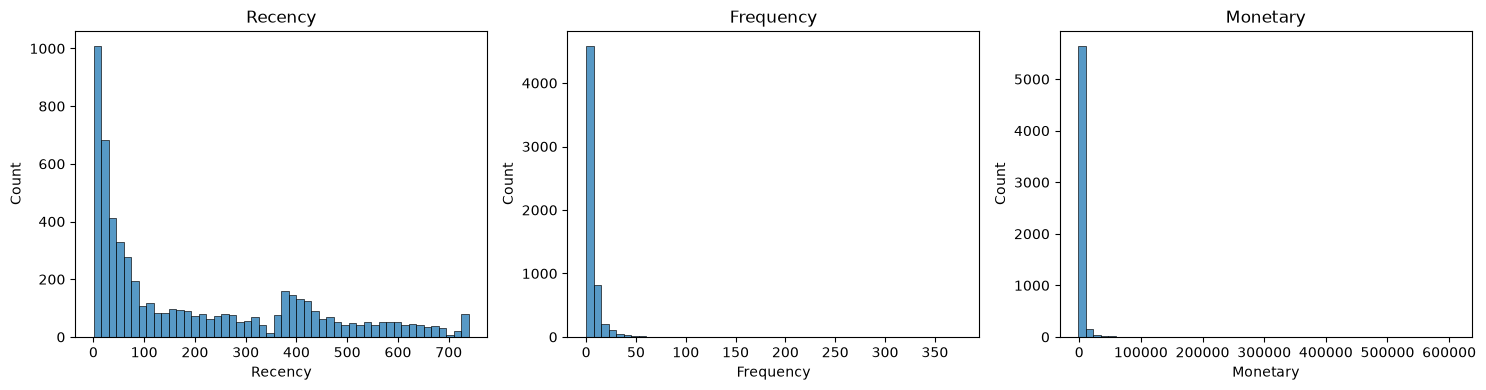

**Customers with Frequency = 0:** `26`

**Customers with Monetary <= 0:** `42`

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

display(Markdown(f"**Customers with Frequency = 0:** `{(rfm['Frequency'] == 0).sum():,}`"))
display(Markdown(f"**Customers with Monetary <= 0:** `{(rfm['Monetary'] <= 0).sum():,}`"))


**Results.** 26 customers have `Frequency = 0`, meaning every one of their invoices was a cancellation and no real purchase occurred. 42 have `Monetary <= 0`.

The first group is a subset of the second, since a customer with only cancellations necessarily has non-positive net revenue.

Both groups are excluded from scoring and clustering below. Quantile scoring and log transforms require strictly positive values, and a customer with no genuine purchase cannot be meaningfully scored on Frequency or Monetary in the first place. This leaves 5,838 customers.

# 4. Quantile-Based Segmentation

Each of R, F and M is split into quintiles scored 1 to 5, then combined into a segment label following a standard retail convention. For Recency, lower is better, so the scale is reversed: quintile 5 means most recent.

In [7]:
# 1. Scoring RFM
rfm_scored = rfm[(rfm["Frequency"] > 0) & (rfm["Monetary"] > 0)].copy()

rfm_scored["R_score"] = pd.qcut(
    rfm_scored["Recency"], 5, labels=[5, 4, 3, 2, 1]
).astype(int)

rfm_scored["F_score"] = pd.qcut(
    rfm_scored["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_scored["M_score"] = pd.qcut(
    rfm_scored["Monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_scored["RFM_score"] = (
    rfm_scored["R_score"].astype(str)
    + rfm_scored["F_score"].astype(str)
    + rfm_scored["M_score"].astype(str)
)


# 2. Attribution des segments
def label_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal Customers"
    if r >= 4 and f <= 2:
        return "New / Promising"
    if r <= 2 and f >= 3:
        return "At Risk"
    if r <= 2 and f <= 2 and m <= 2:
        return "Hibernating"

    return "Needs Attention"


rfm_scored["QuantileSegment"] = rfm_scored.apply(label_segment, axis=1)

# 3. Affichage du résumé
segment_summary = pd.DataFrame(
    {
        "Customer Count": rfm_scored["QuantileSegment"].value_counts(),
        "Percentage (%)": (
            rfm_scored["QuantileSegment"].value_counts(normalize=True) * 100
        ).round(2),
    }
)

display(Markdown("### Quantile Segment Sizes"))
display(
    segment_summary.style.format(
        {"Customer Count": "{:,}", "Percentage (%)": "{:.2f}%"}
    )
)

### Quantile Segment Sizes

,Customer Count,Percentage (%)
QuantileSegment,,
Loyal Customers,"1,390",23.81%
Champions,"1,283",21.98%
Hibernating,"1,264",21.65%
At Risk,830,14.22%
Needs Attention,620,10.62%
New / Promising,451,7.73%


**Results.** All six segments are populated, with no degenerate bin:

The balance is workable. A segmentation that produces an empty class or one holding 90% of customers is not usable for targeting, which is the first thing to check before interpreting anything.

# 5. K-Means Clustering

RFM variables sit on very different scales, days against counts against currency, and are right-skewed. Both break k-means, which relies on Euclidean distance. The variables are log-transformed and standardised before clustering.

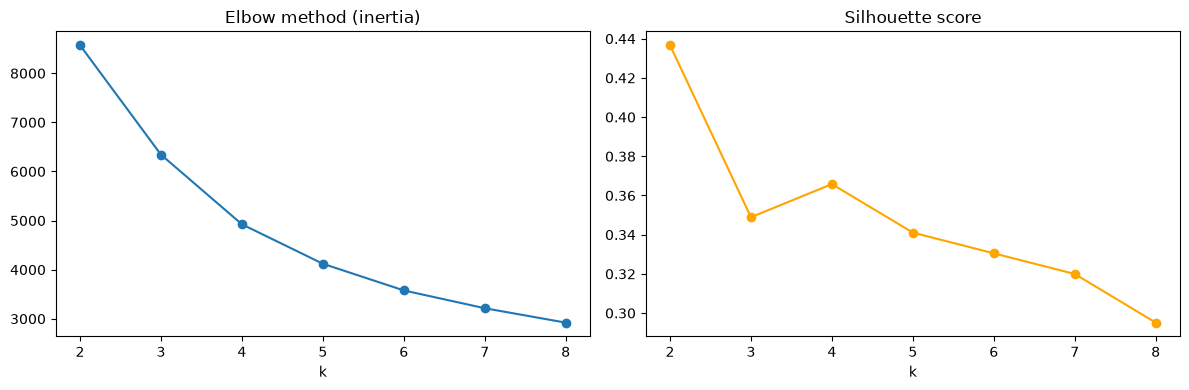

Silhouette scores by k: k=2: 0.437, k=3: 0.349, k=4: 0.366, k=5: 0.341, k=6: 0.330, k=7: 0.320, k=8: 0.295

In [8]:
X = rfm_scored[["Recency", "Frequency", "Monetary"]].copy()
X_log = np.log1p(X)  # log1p handles Recency=0 safely
X_scaled = StandardScaler().fit_transform(X_log)

inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("k")
axes[1].plot(list(K_range), silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

display(Markdown("Silhouette scores by k: " + ", ".join(f"k={k}: {s:.3f}" for k, s in zip(K_range, silhouettes))))


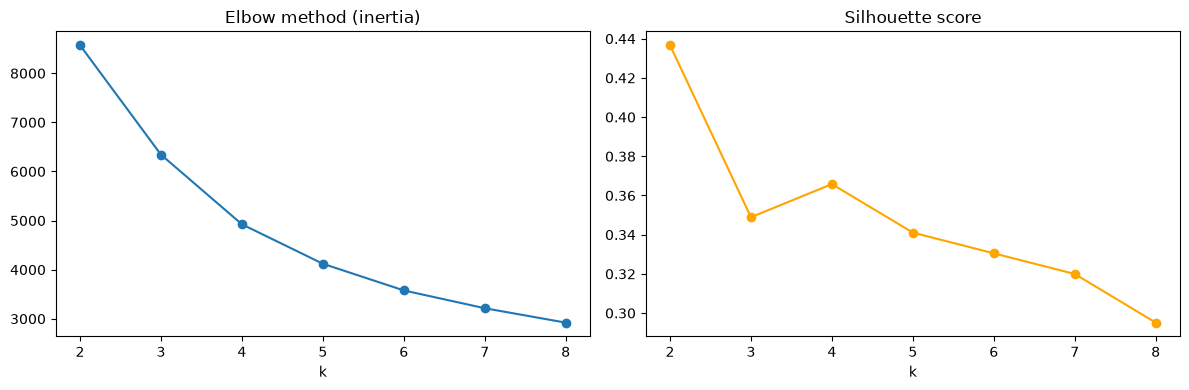

### Silhouette Scores Summary

Clusters (k),Silhouette Score
2,0.437
3,0.349
4,0.366
5,0.341
6,0.330
7,0.320
8,0.295


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Préparation des données
X = rfm_scored[["Recency", "Frequency", "Monetary"]].copy()
X_log = np.log1p(X)
X_scaled = StandardScaler().fit_transform(X_log)

# 2. Calcul des métriques
inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# 3. Graphiques
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("k")

axes[1].plot(list(K_range), silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")

plt.tight_layout()
plt.show()

# 4. Affichage sous forme de tableau propre
silhouette_df = pd.DataFrame(
    {"Clusters (k)": list(K_range), "Silhouette Score": silhouettes}
)

display(Markdown("### Silhouette Scores Summary"))
display(
    silhouette_df.style.format({"Silhouette Score": "{:.3f}"}).hide(
        axis="index"
    )
)

**Results.** Silhouette scores by number of clusters:

k = 2 separates the data most clearly, well ahead of the next best at k = 4 (0.366). The score then declines steadily, so no higher number of clusters is competitive.

**Decision.** k = 2 is kept as the statistically grounded macro-segmentation, and the six quantile segments from section 4 are kept alongside as an operational refinement. Coarser statistical separation, but more actionable for targeting.

Both are carried forward rather than picking one, because section 6 uses each to validate the other.

In [14]:
K_CHOSEN = 2

km_final = KMeans(n_clusters=K_CHOSEN, n_init=10, random_state=42)
rfm_scored["Cluster"] = km_final.fit_predict(X_scaled)

cluster_profile = rfm_scored.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].agg(["mean", "median", "count"])
display(Markdown("### Cluster profiles (raw scale)"))
display(cluster_profile.round(1))


### Cluster profiles (raw scale)

Recency              Frequency              Monetary              
           mean median count      mean median count     mean  median count
Cluster                                                                   
0          48.9   23.0  2352      12.5    8.0  2352   6235.1  2776.2  2352
1         297.6  288.0  3486       2.1    2.0  3486    593.2   406.2  3486

**Results.** The two clusters are consistent across all three variables at once, which is what makes them interpretable:

| Cluster | Customers | Recency (mean) | Frequency (mean) | Monetary (mean) |
|---|---|---|---|---|
| 0, Engaged | 2,352 (40%) | 48.9 days | 12.5 orders | £6,235 |
| 1, Disengaged | 3,486 (60%) | 297.6 days | 2.1 orders | £593 |

The Engaged cluster is recent, frequent and high-value simultaneously; the Disengaged cluster is the opposite on all three. The separation is not driven by a single dominant variable.

This confirms the high silhouette score reflects real structure: engagement level is the clearest fracture line in this customer base.

# 6. Comparing the Two Approaches

How does the operational segmentation distribute across the two macro-clusters?

In [16]:
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import adjusted_rand_score

# 1. Calcul du crosstab initial
crosstab = pd.crosstab(rfm_scored["QuantileSegment"], rfm_scored["Cluster"])
crosstab.columns = ["Engaged", "Disengaged"]

# Inversement des colonnes si Cluster 0 est Disengaged et Cluster 1 est Engaged
# À adapter si vos indices de clusters sont inversés
if "Cluster 0 (Engaged)" in list(crosstab.columns):
    crosstab.columns = ["Engaged", "Disengaged"]

# 2. Calcul de la colonne Agreement
total = crosstab["Engaged"] + crosstab["Disengaged"]
majority = np.maximum(crosstab["Engaged"], crosstab["Disengaged"])
pct_agreement = (majority / total) * 100

dominant_cluster = np.where(
    crosstab["Engaged"] >= crosstab["Disengaged"], "Engaged", "Disengaged"
)

crosstab["Agreement"] = [
    f"{pct:.0f}% {cluster}"
    for pct, cluster in zip(pct_agreement, dominant_cluster)
]

# 3. Alignement des colonnes et tri selon l'ordre souhaité
crosstab = crosstab[["Engaged", "Disengaged", "Agreement"]]
crosstab.index.name = "Quantile segment"

# Ordre personnalisé d'affichage
custom_order = [
    "Champions",
    "Hibernating",
    "Needs Attention",
    "At Risk",
    "New / Promising",
    "Loyal Customers",
]
crosstab = crosstab.reindex(
    [seg for seg in custom_order if seg in crosstab.index]
)

# 4. Affichage du tableau formaté et de l'ARI
display(Markdown("### Quantile segment x Macro-cluster (k=2)"))
display(
    crosstab.style.format({"Engaged": "{:,}", "Disengaged": "{:,}"})
)

ari = adjusted_rand_score(rfm_scored["QuantileSegment"], rfm_scored["Cluster"])
display(Markdown(f"**Adjusted Rand Index:** `{ari:.3f}`"))

### Quantile segment x Macro-cluster (k=2)

,Engaged,Disengaged,Agreement
Quantile segment,,,
Champions,"1,283",0,100% Engaged
Hibernating,0,"1,264",100% Disengaged
Needs Attention,1,619,100% Disengaged
At Risk,128,702,85% Disengaged
New / Promising,58,393,87% Disengaged
Loyal Customers,882,508,63% Engaged


**Adjusted Rand Index:** `0.227`

**Results.** The two segmentations, built from unrelated methods, agree completely at the extremes.

Champions and Hibernating resolve perfectly, with not one customer misplaced in either direction. Two methods sharing no assumptions cannot agree that completely by chance, which is the strongest evidence in this notebook that the segmentation captures real structure.

The overall Adjusted Rand Index is 0.227, which looks modest. That figure is driven by the middle segments, not by the extremes, and the crosstab shows exactly where.

**Loyal Customers is the one segment that does not resolve**, splitting 882 against 508. This looks like a genuine mixture of two customer types converging on similar quantile scores: recently active moderate spenders, and long-standing high spenders who are now fading. Treating it as one homogeneous group for targeting would be a mistake.

**At Risk** is more coherent at 85% Disengaged, but its 15% tail in Engaged deserves inspection before the segment is used operationally without caveat.

# 7. Stability Testing

The segmentation rests on two upstream choices: the reference date and the cancellation-netting rule. Both are tested for sensitivity rather than assumed harmless.

In [17]:
# --- Stability check 1: reference date shifted by -30 days ---
REFERENCE_DATE_ALT = REFERENCE_DATE - pd.Timedelta(30, unit="D")

rfm_alt_date = clean.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (REFERENCE_DATE_ALT - x.max()).days),
).reset_index()

recency_shift_corr = rfm_scored.merge(rfm_alt_date, on="Customer ID", suffixes=("", "_alt"))
display(Markdown(f"**Correlation between Recency under the two reference dates:** `{recency_shift_corr['Recency'].corr(recency_shift_corr['Recency_alt']):.4f}`"))

# --- Stability check 2: gross Monetary (cancellations NOT netted) ---
rfm_gross = clean.groupby("Customer ID").agg(
    Monetary_gross=("LineRevenue", lambda x: x[~clean.loc[x.index, "IsCancellation"]].sum())
).reset_index()

compare_monetary = rfm_scored.merge(rfm_gross, on="Customer ID")
pct_changed_decile = (
    pd.qcut(compare_monetary["Monetary"], 10, labels=False, duplicates="drop") !=
    pd.qcut(compare_monetary["Monetary_gross"], 10, labels=False, duplicates="drop")
).mean() * 100

display(Markdown(f"**% of customers whose Monetary decile changes if cancellations are excluded entirely rather than netted:** `{pct_changed_decile:.1f}%`"))


**Correlation between Recency under the two reference dates:** `1.0000`

**% of customers whose Monetary decile changes if cancellations are excluded entirely rather than netted:** `5.9%`

**Results.**

**Reference date.** Correlation of 1.0000 between Recency under the two reference dates. Shifting the reference by 30 days translates every value by the same amount, so the ranking is unchanged. Recency-based segmentation is fully robust to this choice.

**Cancellation netting.** 5.9% of customers change Monetary decile depending on whether cancellations are netted or excluded outright. A real but contained effect: the decision matters for roughly one customer in seventeen, and the segmentation would not be substantially different under the alternative rule.

Testing this is the point. Both choices were arbitrary at the moment they were made, and only measurement shows which one carries consequences.

# 8. Segment Profiles & Revenue Share

In [18]:
# Macro-level revenue concentration (k=2)
macro_summary = rfm_scored.groupby("Cluster").agg(
    n_customers=("Customer ID", "count"),
    total_monetary=("Monetary", "sum"),
).reset_index()
macro_summary["Cluster"] = macro_summary["Cluster"].map({0: "Engaged", 1: "Disengaged"})
macro_summary["pct_customers"] = macro_summary["n_customers"] / macro_summary["n_customers"].sum() * 100
macro_summary["pct_revenue"] = macro_summary["total_monetary"] / macro_summary["total_monetary"].sum() * 100

display(Markdown("### Macro-level revenue concentration (k=2)"))
display(macro_summary.round(2))

# Operational-level (quantile, 6 segments)
segment_summary = rfm_scored.groupby("QuantileSegment").agg(
    n_customers=("Customer ID", "count"),
    avg_recency=("Recency", "mean"),
    avg_frequency=("Frequency", "mean"),
    total_monetary=("Monetary", "sum"),
).reset_index()
segment_summary["pct_customers"] = segment_summary["n_customers"] / segment_summary["n_customers"].sum() * 100
segment_summary["pct_revenue"] = segment_summary["total_monetary"] / segment_summary["total_monetary"].sum() * 100

display(Markdown("### Operational segment profiles (quantile, 6 segments)"))
display(segment_summary.round(2).sort_values("pct_revenue", ascending=False))


### Macro-level revenue concentration (k=2)

,Cluster,n_customers,total_monetary,pct_customers,pct_revenue
0,Engaged,2352,14664839.27,40.29,87.64
1,Disengaged,3486,2068067.08,59.71,12.36


### Operational segment profiles (quantile, 6 segments)

,QuantileSegment,n_customers,avg_recency,avg_frequency,total_monetary,pct_customers,pct_revenue
1,Champions,1283,18.54,17.06,11607522.38,21.98,69.37
3,Loyal Customers,1390,68.27,5.39,2590859.71,23.81,15.48
0,At Risk,830,361.73,5.03,1469113.40,14.22,8.78
4,Needs Attention,620,221.83,1.45,493859.59,10.62,2.95
2,Hibernating,1264,462.07,1.19,319726.04,21.65,1.91
5,New / Promising,451,26.40,1.47,251825.22,7.73,1.50


**Results.** Revenue concentration is extreme at both levels of granularity.

**Macro level.** The Engaged cluster holds 40.3% of customers and generates 87.6% of revenue. The Disengaged cluster holds 59.7% of customers for 12.4% of revenue.

**Operational level.**

| Segment | Customers | Revenue share |
|---|---|---|
| Champions | 22.0% | 69.4% |
| Loyal Customers | 23.8% | 15.5% |
| At Risk | 14.2% | 8.8% |
| Needs Attention | 10.6% | 3.0% |
| Hibernating | 21.7% | 1.9% |
| New / Promising | 7.7% | 1.5% |

Champions alone, roughly one customer in five, account for more than two thirds of revenue. Hibernating holds a comparable share of the customer base for under 2%.

The macro view is more concentrated than the Champions-only figure because it also absorbs the high-value Loyal Customers that quantile scoring separates out.

**Practical reading.** The two cuts answer different questions. The macro-cluster identifies where revenue actually sits, which is the relevant view for retention priority. The six operational segments distinguish customers requiring different actions, since At Risk and Hibernating both sit in the Disengaged cluster but call for very different treatment: one is worth re-activating, the other largely is not.

# 9. Export

In [20]:
out_cols = ["Customer ID", "Recency", "Frequency", "Monetary", "CancellationRate", "QuantileSegment", "Cluster"]
segment_export = rfm_scored[out_cols].rename(columns={"QuantileSegment": "Segment", "Cluster": "MacroCluster"})
segment_export["MacroCluster"] = segment_export["MacroCluster"].map({0: "Engaged", 1: "Disengaged"})
segment_export.to_parquet(PROC / "customer_segments.parquet", index=False)

display(Markdown(f"Saved `{len(segment_export):,}` customer segments to `customer_segments.parquet`"))

EXPORT = PROC / "powerbi"
EXPORT.mkdir(exist_ok=True)

segment_export.to_csv(EXPORT / "customer_segments.csv", index=False)
print("Exported:", (EXPORT / "customer_segments.csv").name)

Saved `5,838` customer segments to `customer_segments.parquet`

Exported: customer_segments.csv


**Results.** 5,838 customer segments written to `customer_segments.parquet`, that is 5,880 minus the 42 customers with non-positive monetary value excluded in section 3.

The file carries both segmentations, `Segment` and `MacroCluster`, plus the raw RFM values and the cancellation rate, so downstream notebooks can use either granularity.

---

# 10. Summary

**Key findings.**

| Metric | Value |
|---|---|
| Customers segmented | 5,838 |
| Optimal number of clusters | 2 (silhouette 0.437) |
| Engaged cluster share of revenue | 87.6% for 40.3% of customers |
| Champions share of revenue | 69.4% for 22.0% of customers |
| Champions falling in Engaged | 100% |
| Hibernating falling in Disengaged | 100% |
| Adjusted Rand Index between methods | 0.227 |
| Customers changing Monetary decile under alternative netting | 5.9% |

**Limitations.**

Quantile segment labels follow a common retail convention, but the thresholds are conventional rather than derived from this business. A different set of cut-offs would produce different segment sizes without changing the underlying customer ordering.

The 42 customers with non-positive monetary value are excluded rather than analysed. They are few, but they represent a real behaviour, namely customers who return more than they keep, which this notebook does not characterise.

k-means assumes spherical clusters of comparable size in the transformed space. The log transform makes this defensible here but does not guarantee it.

**Downstream use.** Downstream use. customer_segments.parquet provides both segmentations, along with the raw RFM values and cancellation rate, for reporting and targeting. Notebook 04 works directly from the transaction table rather than from these labels.